**AdaBoost and Gradient Boosting via Sklearn**
- **Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- **Objective:** Familiarize yourself with standard boosting algorithms and the concept of learning rates.
- **Task:** Train an AdaBoostClassifier and a GradientBoostingClassifier on a structured dataset.
- **Requirements:**  
               - Create a grid search (GridSearchCV) to tune the learning_rate and n_estimators.  
               - Plot the relationship between the number of estimators and the training/validation error.  
               - Question to answer: At what point does the Gradient Boosting model start to overfit, and how does the learning rate affect this point?

Loading dataset...

--- Tuning AdaBoost ---
Best AdaBoost Params: {'learning_rate': 0.2, 'n_estimators': 150}

--- Tuning Gradient Boosting ---
Best Gradient Boosting Params: {'learning_rate': 0.01, 'n_estimators': 150}

AdaBoost Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.55      0.66       148

    accuracy                           1.00     85443
   macro avg       0.91      0.78      0.83     85443
weighted avg       1.00      1.00      1.00     85443


Gradient Boosting Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.93      0.62      0.74       148

    accuracy                           1.00     85443
   macro avg       0.96      0.81      0.87     85443
weighted avg       1.00      1.00      1.00     85443



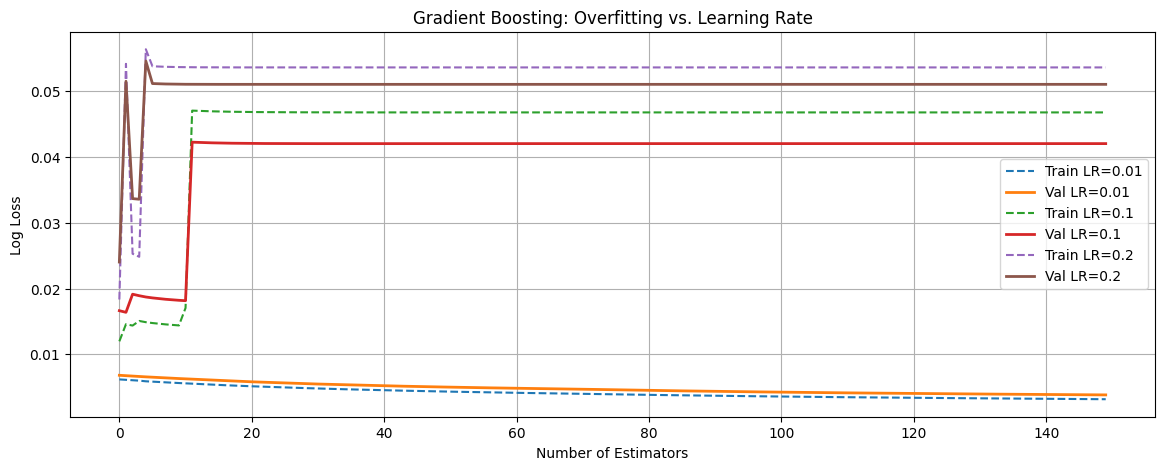

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, log_loss

# 1. Load and Preprocess Dataset
print("Loading dataset...")
df = pd.read_csv('creditcard.csv')

# Drop Time, scale Amount
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

# Stratified split to maintain class proportions
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 2. Grid Search for Hyperparameter Tuning
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150]
}

print("\n--- Tuning AdaBoost ---")
ada_grid = GridSearchCV(AdaBoostClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
ada_grid.fit(X_train, y_train)
print(f"Best AdaBoost Params: {ada_grid.best_params_}")

print("\n--- Tuning Gradient Boosting ---")
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f"Best Gradient Boosting Params: {gb_grid.best_params_}")

# 3. Evaluate Best Models
print("\nAdaBoost Evaluation:")
print(classification_report(y_val, ada_grid.predict(X_val)))

print("\nGradient Boosting Evaluation:")
print(classification_report(y_val, gb_grid.predict(X_val)))

# 4. Plot Overfitting and Learning Rate Analysis
# We will track deviance (log-loss) over iterations for different learning rates
rates = [0.01, 0.1, 0.2]
n_est = 150

plt.figure(figsize=(14, 5))

for lr in rates:
    gb = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
    gb.fit(X_train, y_train)
    
    # Calculate log loss at each boosting stage
    train_loss = [log_loss(y_train, y_pred) for y_pred in gb.staged_predict_proba(X_train)]
    val_loss = [log_loss(y_val, y_pred) for y_pred in gb.staged_predict_proba(X_val)]
    
    plt.plot(train_loss, label=f'Train LR={lr}', linestyle='--')
    plt.plot(val_loss, label=f'Val LR={lr}', linewidth=2)

plt.title('Gradient Boosting: Overfitting vs. Learning Rate')
plt.xlabel('Number of Estimators')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)
plt.show()

**Extreme Gradient Boosting (XGBoost/LightGBM)**
- **Dataset:** https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
- **Objective:** Utilize industry-standard libraries to handle real-world challenges like class imbalance and early stopping.
- **Task:** Use the xgboost or lightgbm library on a highly imbalanced dataset (e.g., Credit Card Fraud Detection).
- **Requirements:**  
             - Implement Early Stopping by using a dedicated validation set during the training loop to halt training when validation log-loss stops improving.  
             - Handle the class imbalance using the scale_pos_weight parameter or by utilizing focal loss.  
             - Use SHAP (SHapley Additive exPlanations) values to interpret the most important features driving the model's predictions.

In [5]:
!python3 -m pip install xgboost shap

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 1.6 MB/s eta 0:00:01
     |████████████████████████████████| 556 kB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.7 MB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 2.1 MB/s eta 0:00:01
     |████████████████████████████████| 28.8 MB 575 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Training halted early at iteration: 256

XGBoost Test Set Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56863
           1       0.86      0.83      0.85        99

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Area Under PR-Curve: 0.8658

Calculating SHAP values...


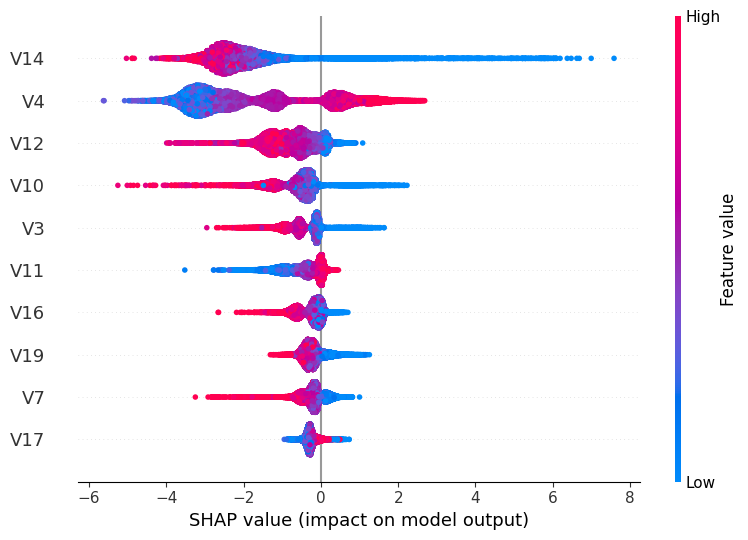

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, average_precision_score
import xgboost as xgb
import shap

# 1. Load and Preprocess Dataset
df = pd.read_csv('creditcard.csv')
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
# Split into Train, Validation, and Test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 2. Handle Class Imbalance
# scale_pos_weight = total_negative_examples / total_positive_examples
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_weight = num_neg / num_pos

# 1. Define early_stopping_rounds inside the constructor
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=num_neg / num_pos,
    eval_metric="logloss",
    early_stopping_rounds=10  # <-- Moved here
)

# 2. Clean up the fit method
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f"Training halted early at iteration: {model.best_iteration}")

# 4. Evaluate on Test Set
y_pred = model.predict(X_test)
print("\nXGBoost Test Set Evaluation:")
print(classification_report(y_test, y_pred))
print(f"Area Under PR-Curve: {average_precision_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

# 5. SHAP (SHapley Additive exPlanations) Explanations
print("\nCalculating SHAP values...")
# Using TreeExplainer optimize for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Plot Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, max_display=10)